In [4]:
import os
import sys
from os import path
sys.path.append(os.path.expanduser('~/albatros_analysis'))
import numpy as np 
import numba as nb
import time
from scipy import linalg
from scipy import stats
from matplotlib import pyplot as plt
from datetime import datetime as dt
from src.correlations import baseband_data_classes as bdc
from src.utils import baseband_utils as butils
from src.utils import orbcomm_utils as outils
import json
import argparse
from scipy.optimize import least_squares
import coord_helper as ch
import extra_functions as ef
import h5py
import skyfield.api as sf
import importlib
from numpy.linalg import inv
import numbers

BDC is using numpy


In [27]:
day = '09_11'
bits = 1
baseline_idx = 1

config_file_name = f'config_{day}.json'
working_directory = '/project/s/sievers/thomasb/mars_data_24'

In [28]:
with open(f"{working_directory}/{bits}bit/{day}/{config_file_name}", "r") as f:
    config = json.load(f)
    dir_parents = []
    coords = []
    # unpack information from the json file
    # Call get_starting_index for all antennas except reference
    for i, (ant, details) in enumerate(config["antennas"].items()):
        if (i == 0) or (i ==baseline_idx):
            coords.append(details['coordinates'])
            dir_parents.append(details["path"])
    global_start_time = config["correlation"]["start_timestamp"]
    end_t = config["correlation"]["end_timestamp"]
    v_acclen = config["correlation"]["vis_acclen"]
    visibility_window = config["correlation"]["visibility_window"]
    T_SPECTRA = config["correlation"]["point_PFB"] / config["correlation"]["sample_rate"]


ref_coords = coords[0]
v_nchunks = int((visibility_window)/(v_acclen* T_SPECTRA))

context = [visibility_window, T_SPECTRA, v_acclen, v_nchunks, ref_coords]
print(global_start_time)

1699508012


In [29]:
pl = []

with h5py.File(f'{working_directory}/{bits}bit/{day}/vis_selected_bline_{baseline_idx}_{global_start_time}.h5', 'r') as f:
    for p in f:
        pulse_info = []
        pulse_info.append(p)
        pulse_info.append([f[p].attrs['start_time'], f[p].attrs['end_time'], int(f[p].attrs['global_start_time'])])
        pulse_info.append([int(f[p].attrs['sat']), int(f[p].attrs['chan'])])
        pulse_info.append(f[p].attrs['tle_path'])
        pulse_info.append(f[f'/{p}'][:])
        pl.append(pulse_info)

print(pl[4][:3])

['15_43440', [np.float64(43636.608), np.float64(43833.216), 1699508012], [33591, 1850]]


SAT DELAY TESTING

In [6]:
importlib.reload(outils)

<module 'src.utils.orbcomm_utils' from '/home/s/sievers/thomasb/albatros_analysis/src/utils/orbcomm_utils.py'>

In [7]:
old_delay = outils.get_sat_delay(coords[0], coords[1], pl[0][3], pl[0][1][0], int(pl[0][1][1] - pl[0][1][0]), 57166)
new_delay = outils.get_sat_delay_new(coords[0], coords[1], pl[0][3], pl[0][1][0], int(pl[0][1][1] - pl[0][1][0]), 57166)

catalog #57166 epoch 2023-11-08 21:41:03 UTC
one delay prediction: 0.13305020332336426
time for one delay pred: 0.05260944366455078


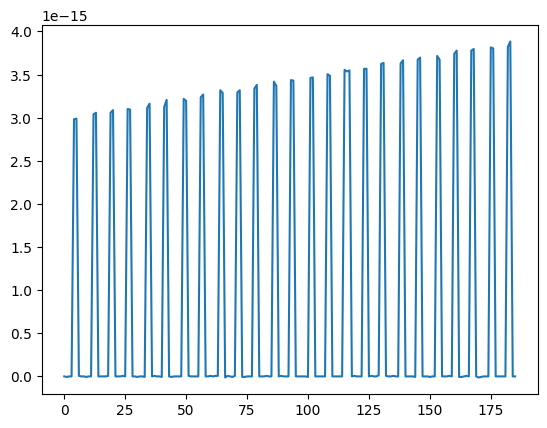

In [8]:
plt.plot(old_delay-new_delay)

result: minimal differences. they do the same thing.

PHASE PREDICTION TESTING

In [56]:
importlib.reload(ch)
importlib.reload(ef)

<module 'extra_functions' from '/home/s/sievers/thomasb/albatros_analysis/scripts/orbcomm/fitting/extra_functions.py'>

In [10]:
idx = 4
dt = 4

new_phase = ef.pred(coords[1], dt, idx, pl, context)
true_phase = ef.true_pred(coords[1], dt, idx, pl, context)
true_phase0 = ef.true_pred(coords[1], 0, idx, pl, context)

print(len(pl[idx][4]))
print(len(new_phase))
print(len(true_phase))

time for one delay pred: 0.010109901428222656
time taken pred 0.010267019271850586
time for one delay pred: 0.008927345275878906
time taken true_pred: 0.009016275405883789
time for one delay pred: 0.00880742073059082
time taken true_pred: 0.008893728256225586
200
204
200


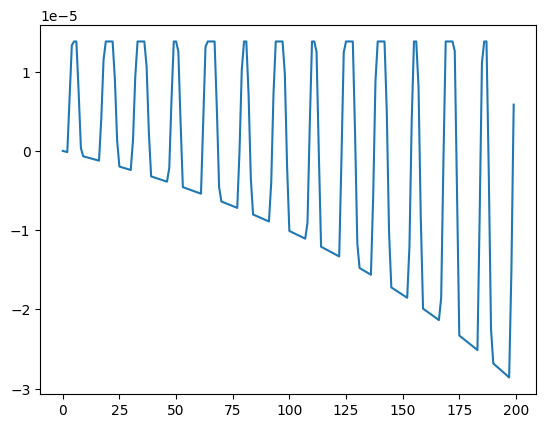

In [11]:
plt.plot(true_phase[:len(pl[idx][4])] - new_phase[:len(pl[idx][4])])

result: it works. the true prediction (simplest possible setup that I know to be true) has very small difference with my new function. PRED WORKS.

TESTING MOHAN VS THOMAS METHODS

In [12]:
idx = 3
differences = []
times = np.arange(-4, 4, 0.25)
print(times)

for dt in times:
    differences.append(np.max(np.abs(ef.pred(coords[1], dt, idx, pl, context)[:len(pl[idx][4])] - ef.pred_mohan(coords[1], dt, idx, pl, context)[:len(pl[idx][4])])))

[-4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25 -2.   -1.75 -1.5  -1.25
 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75  1.    1.25  1.5   1.75
  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75]
time for one delay pred: 0.007359743118286133
time taken pred 0.007458686828613281
time for one delay pred: 0.006670951843261719
time taken for one prediction 0.006758451461791992
time for one delay pred: 0.00701451301574707
time taken pred 0.0070934295654296875
time for one delay pred: 0.006568193435668945
time taken for one prediction 0.006645917892456055
time for one delay pred: 0.006850242614746094
time taken pred 0.00693058967590332
time for one delay pred: 0.006629228591918945
time taken for one prediction 0.0067043304443359375
time for one delay pred: 0.006983518600463867
time taken pred 0.007061481475830078
time for one delay pred: 0.006608247756958008
time taken for one prediction 0.006682395935058594
time for one delay pred: 0.00698399543762207
time taken pred 0.007060527801513672
ti

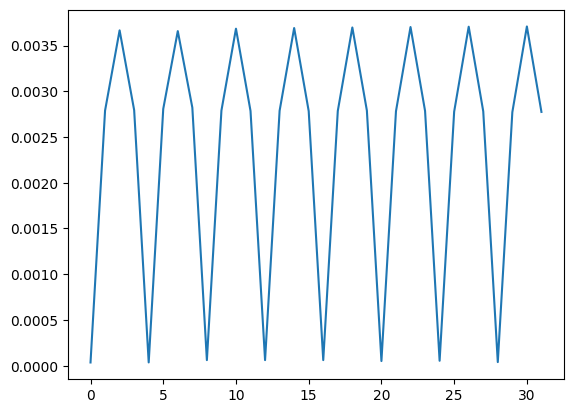

In [13]:
plt.plot(differences)

thomas function works up until a dt of 4. otherwise the difference is negligible. PRED WORKS

TESTING TIME OFFSETS DT

In [18]:
offsets = ef.offset_fit(coords[1], ef.pred, pl, context)

time for one delay pred: 0.014032840728759766
time taken pred 0.01425313949584961
time for one delay pred: 0.012920856475830078
time taken pred 0.013010740280151367
time for one delay pred: 0.012939929962158203
time taken pred 0.01302957534790039
time for one delay pred: 0.012845754623413086
time taken pred 0.012931108474731445
time for one delay pred: 0.012807846069335938
time taken pred 0.012894630432128906
time for one delay pred: 0.012826681137084961
time taken pred 0.01291036605834961
time for one delay pred: 0.012924671173095703
time taken pred 0.013010501861572266
time for one delay pred: 0.012709379196166992
time taken pred 0.012794256210327148
time for one delay pred: 0.013151168823242188
time taken pred 0.013240814208984375
time for one delay pred: 0.012745857238769531
time taken pred 0.012831449508666992
time for one delay pred: 0.012751102447509766
time taken pred 0.012838363647460938
time for one delay pred: 0.012819051742553711
time taken pred 0.01291036605834961
time for

In [15]:
print(offsets)

[array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.])]


In [16]:
offsets2 = ef.offset_fit(coords[1], ef.pred_mohan, pl, context)

time for one delay pred: 0.012787818908691406
time taken for one prediction 0.012975454330444336
time for one delay pred: 0.012568950653076172
time taken for one prediction 0.012656211853027344


time for one delay pred: 0.013799428939819336
time taken for one prediction 0.013985157012939453
time for one delay pred: 0.01331186294555664
time taken for one prediction 0.013399124145507812
time for one delay pred: 0.006468057632446289
time taken for one prediction 0.006545543670654297
time for one delay pred: 0.006725788116455078
time taken for one prediction 0.0068018436431884766
time for one delay pred: 0.006719350814819336
time taken for one prediction 0.006802797317504883
time for one delay pred: 0.006578683853149414
time taken for one prediction 0.006661415100097656
time for one delay pred: 0.008798360824584961
time taken for one prediction 0.00887751579284668
time for one delay pred: 0.008686065673828125
time taken for one prediction 0.008764982223510742
time for one delay pred: 0.009509801864624023
time taken for one prediction 0.009590387344360352
time for one delay pred: 0.009606599807739258
time taken for one prediction 0.009685516357421875
time for one delay pred: 0.0099

In [17]:
print(offsets2)

[array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.]), array([0.])]


THOMAS METHOD WORKS FOR OFFSETS, MOHAN'S DOES NOT.

TESTING SOLID FIT

In [57]:
joint1 = ef.joint_fit(coords[1], ef.pred, pl, context)

time for one delay pred: 0.013737916946411133
time taken pred 0.014023065567016602
time for one delay pred: 0.009264230728149414
time taken pred 0.009361505508422852
time for one delay pred: 0.01870107650756836
time taken pred 0.018807649612426758
time for one delay pred: 0.010235309600830078
time taken pred 0.010324954986572266
time for one delay pred: 0.013514041900634766
time taken pred 0.01360630989074707
time for one delay pred: 0.009153604507446289
time taken pred 0.009240865707397461
time for one delay pred: 0.013124227523803711
time taken pred 0.013214349746704102
time for one delay pred: 0.009057760238647461
time taken pred 0.009146928787231445
time for one delay pred: 0.009048938751220703
time taken pred 0.009134769439697266
time for one delay pred: 0.010116100311279297
time taken pred 0.010201454162597656
time for one delay pred: 0.011129140853881836
time taken pred 0.011216163635253906
time for one delay pred: 0.013234376907348633
time taken pred 0.013324737548828125
time f

NameError: name 'param_err' is not defined

In [31]:
print(solid1)

[ 79.4172642  -90.75863175 170.55192814]


time for one delay pred: 0.013120889663696289
time taken pred 0.013480186462402344


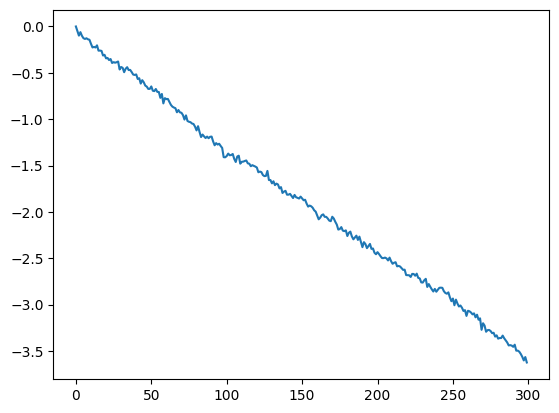

In [51]:
plt.plot(ef.std_res_ind(solid1, 0, 10, ef.pred,  pl, context))